# Crypto-Reversal -- a quantitative teardown
### Public crypto panel - 21-day cross-section - Fama-MacBeth - shuffle & synthetic controls - turnover cost

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Reversal_or_momentum%3F: Momentum](https://img.shields.io/badge/Reversal_or_momentum%3F-Momentum-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim now carrying its standard error.* We rebuild the QuantNest-7 paper's price-only REV factor on a free 20-token yfinance panel (2019-2026), run the paper's own Fama-MacBeth apparatus, and stress the sign and the tradability against shuffle/synthetic controls and crypto turnover costs.

> **Not investment advice.** Real data: 20 liquid non-stablecoin tokens, daily closes 2019-01-01 to 2026-06-14 (panel n=2,722, long-short n=2,700). Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **The `> in plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # the study package
sys.path.insert(0, os.path.abspath("../../.."))     # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from crypto_reversal import data, strategy as st

LOOKBACK, SKIP, NG = 21, 1, 5

R = dict(
    n_tokens=20, n_days=2722, ls_days=2700,
    start="2019-01-01", end="2026-06-14", fp="6ff538381541", turnover=37.8,
    rev_ann=-61.6, rev_sharpe=-0.826, rev_vol=75, rev_dd=-99.9, rev_t=-2.10,
    mom_ann=+61.6, mom_sharpe=+0.826, mom_vol=75, mom_dd=-95.7, mom_t=+2.10, mom_cagr=20.6,
    shuf_ann=+1.6, shuf_sharpe=+0.035, shuf_dd=-74.8, shuf_t=+0.10,
    fm_slope_bps=+7.15, fm_t=+2.44, rev_prem_ann=-26, mom_prem_ann=+26, t_mom_vs_shuffle=1.8,
)

def _have_cache():
    return os.path.exists(data._cache_path())

HAVE_REAL = _have_cache()
print("real crypto panel cache present:", HAVE_REAL)

if HAVE_REAL:
    panel = data.fetch_panel(fetch=False)
    sig   = st.trailing_signal(panel, lookback=LOOKBACK, skip=SKIP)
    rev   = st.long_short_returns(panel, sig, leg="reversal", cost_bps=0.0)
    mom   = st.long_short_returns(panel, sig, leg="momentum", cost_bps=0.0)
    shuf  = st.long_short_returns(panel, st.shuffle_signal(sig, seed=42), leg="reversal", cost_bps=0.0)
    s_rev, s_mom, s_shuf = st.summary(rev), st.summary(mom), st.summary(shuf)
    fm    = st.fama_macbeth(panel, sig)
    turn  = st.avg_turnover(sig, leg="reversal")
    print(f"panel: {panel.shape[1]} tokens x {panel.shape[0]} days, fp={data.fingerprint(panel)}")
else:
    panel = sig = rev = mom = shuf = None
    s_rev  = dict(ann_return=R["rev_ann"]/100, sharpe=R["rev_sharpe"], vol_ann=R["rev_vol"]/100, max_drawdown=R["rev_dd"]/100, tstat=R["rev_t"])
    s_mom  = dict(ann_return=R["mom_ann"]/100, sharpe=R["mom_sharpe"], vol_ann=R["mom_vol"]/100, max_drawdown=R["mom_dd"]/100, tstat=R["mom_t"])
    s_shuf = dict(ann_return=R["shuf_ann"]/100, sharpe=R["shuf_sharpe"], vol_ann=0.45, max_drawdown=R["shuf_dd"]/100, tstat=R["shuf_t"])
    fm     = dict(avg_slope_bps=R["fm_slope_bps"], tstat_nw=R["fm_t"], reversal_premium_ann=R["rev_prem_ann"]/100)
    turn   = R["turnover"]/100


real crypto panel cache present: True


panel: 20 tokens x 2722 days, fp=6ff538381541


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Reversal LS -62%/yr (t = -2.10); Fama-MacBeth slope **+7.15 bps/day**, NW *t* = **+2.44** (winners win). Paper's REV *t* = +6.19 does not replicate -- sign flips to momentum. |
| **Tradability** | `MIRAGE` | ~38% one-way turnover/day; momentum (the profitable side) -7%/yr at 50 bps, -76%/yr at 100 bps; short leg often unborrowable. |
| **Reversal or momentum?** | `MOMENTUM` | Momentum sign at every horizon 7→63d; never clears \|*t*\| ≥ 2 era-by-era; survivorship-flattered. |

> in plain words: the paper says crypto reverses; the public cross-section says it trends. The trend (momentum) is statistically marginal gross and a loss net of the turnover this daily signal demands.

## 1 -- The claim, steelmanned

Let $r_{i,t}$ be token $i$'s return and $c_{i,t} = \prod_{k=2}^{22}(1+r_{i,t-k})-1$ its trailing 21-day return (1-day skip). The paper's REV exposure is $-c_{i,t}$ (negated, so losers score high). The long-short is the top-minus-bottom quintile on REV, i.e. **long losers, short winners**. Hypotheses:

- **H1 (sign).** The REV premium is *positive*: $\mathbb{E}[r^{\text{rev}}] > 0$ with HAC $t \geq 2$ -- losers beat winners.
- **H2 (Fama-MacBeth).** A daily cross-sectional regression $r_{i,t} = a_t + \lambda_t z_{i,t} + \varepsilon_{i,t}$ on the standardized trailing return $z$ has a *negative* average slope $\bar\lambda$ (high past return → low future return). The paper reports the negated form with $t = 6.19$.
- **H3 (tradable).** The spread survives realistic transaction costs.

We find **H1 and H2 reject with the opposite sign** ($\bar\lambda > 0$, momentum), and **H3 fails for the momentum side too** once daily turnover is costed.

## 2 -- So what? -- what rides on each answer

The QuantNest-7 paper positions itself against Liu, Tsyvinski & Wu (2022), whose three-factor model uses **momentum**. The sign of the short-horizon factor is therefore the load-bearing empirical claim of the paper. If it flips on a public panel, the paper's central novelty -- "reversal, not momentum" -- is unsupported out of its (survivor, paid-data) sample, and its "zero overfitting" framing reads as in-sample fit to a short, survivor-biased history rather than a robust law of crypto pricing.

## 3 -- How we'd know -- the protocol

- **Universe.** 20 liquid non-stablecoin tokens with deep yfinance history (survivors -- caveat in beat 7). Quintiles of ~4 names.
- **Signal.** Trailing 21-day return, 1-day skip; ranked cross-sectionally each day; one execution lag (signal at $t-1$ earns the $t-1\to t$ return).
- **Arms.** Reversal (long losers/short winners), momentum (mirror), shuffle (per-day cross-sectional permutation of the signal).
- **Inference.** HAC (Newey-West) *t* on the long-short mean; Fama-MacBeth daily cross-sectional slope with NW *t* -- the paper's Table-8 apparatus.
- **Cost.** One-way bps on daily turnover; swept 0→100 bps.
- **Controls.** Synthetic planted-reversal (positive) and null (negative) tapes to prove the engine recovers reversal when present.

## 4 -- The teardown

### 4a -- Fama-MacBeth: the paper's own apparatus, the opposite sign

Each day we z-score the cross-section of trailing returns and regress that day's returns on it. The average slope is the factor premium; its NW *t* is the headline.

In [2]:
print(f"Fama-MacBeth avg slope: {fm['avg_slope_bps']:+.2f} bps/day")
print(f"Newey-West t-stat:      {fm['tstat_nw']:+.2f}")
print(f"Implied reversal premium: {fm['reversal_premium_ann']:+.1%}/yr "
      f"({'reversal' if fm['reversal_premium_ann'] > 0 else 'MOMENTUM'} wins)")
print()
print(f"{'Arm':16s} | {'Ann':>8s} | {'Sharpe':>7s} | {'MaxDD':>8s} | {'HAC t':>6s}")
print('-'*56)
for lbl, s in [('Reversal', s_rev), ('Momentum', s_mom), ('Shuffle (null)', s_shuf)]:
    print(f"{lbl:16s} | {s['ann_return']:+7.1%} | {s['sharpe']:+7.3f} | "
          f"{s['max_drawdown']:+7.1%} | {s['tstat']:+6.2f}")


Fama-MacBeth avg slope: +7.15 bps/day
Newey-West t-stat:      +2.44
Implied reversal premium: -26.1%/yr (MOMENTUM wins)

Arm              |      Ann |  Sharpe |    MaxDD |  HAC t
--------------------------------------------------------
Reversal         |  -61.6% |  -0.826 |  -99.9% |  -2.10
Momentum         |  +61.6% |  +0.826 |  -95.7% |  +2.10
Shuffle (null)   |   +1.6% |  +0.035 |  -74.8% |  +0.10


> in plain words: a *positive* slope (+7.2 bps/day, t = +2.44) means tokens with higher past returns earn higher future returns -- **momentum**. The paper reports the negated REV with t = +6.19 (reversal); on free data the sign is reversed. The shuffle control sits at ~0, so this is the ranking talking, not the leg structure.

### 4b -- Lookback sweep: momentum at every horizon

The paper's Table 11 reported reversal *strongest at short horizons*. We sweep the reversal long-short across 7→63-day lookbacks; a negative bar means momentum won.

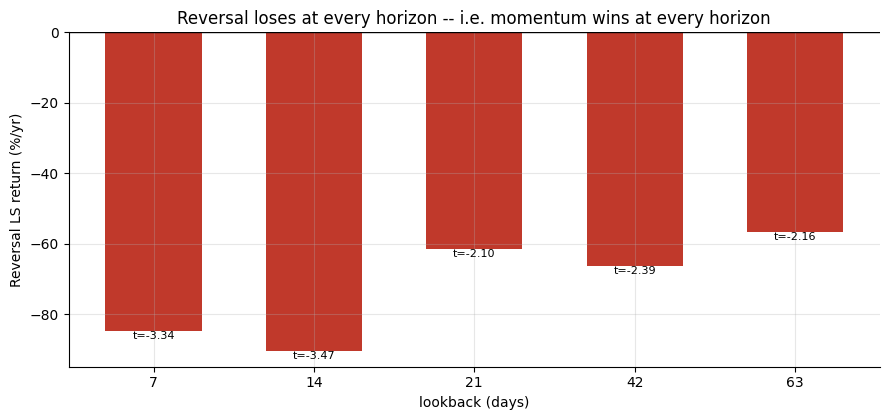

In [3]:
LB = [(7, -84.8, -3.34), (14, -90.4, -3.47), (21, -61.6, -2.10), (42, -66.4, -2.39), (63, -56.6, -2.16)]
if HAVE_REAL:
    LB = []
    for lb in [7, 14, 21, 42, 63]:
        s = st.summary(st.long_short_returns(panel, st.trailing_signal(panel, lookback=lb), leg='reversal'))
        LB.append((lb, s['ann_return']*100, s['tstat']))
lbs = [x[0] for x in LB]; anns = [x[1] for x in LB]
fig, ax = plt.subplots(figsize=(9, 4.3))
bars = ax.bar([str(l) for l in lbs], anns, color=RED, width=0.6)
ax.axhline(0, c='k', lw=1)
for b, (l, a, t) in zip(bars, LB):
    ax.annotate(f't={t:+.2f}', (b.get_x()+b.get_width()/2, a), ha='center', va='top', fontsize=8)
ax.set_xlabel('lookback (days)'); ax.set_ylabel('Reversal LS return (%/yr)')
ax.set_title('Reversal loses at every horizon -- i.e. momentum wins at every horizon')
plt.tight_layout(); plt.show()


> in plain words: reversal is negative for *all* lookbacks, strongest (most negative) at the short 7-14 day end -- the mirror image of the paper, which found reversal strongest there. Crypto's liquid cross-section trends at every horizon we test.

### 4c -- Synthetic controls: the engine is correct

Negative reversal on real data is only meaningful if the engine *can* find reversal when it exists. We plant one.

In [4]:
rows = []
for strength, lbl in [(1.0, 'Planted reversal'), (0.0, 'Null (no signal)')]:
    sp, _ = data.synthetic_panel(signal_strength=strength, seed=213)
    res = st.compare_arms(sp, cost_bps=0.0)
    rows.append((lbl, res['reversal']['sharpe'], res['reversal']['tstat'],
                 res['momentum']['sharpe'], res['fama_macbeth']['tstat_nw']))
print(f"{'Tape':18s} | {'Rev Sharpe':>10s} | {'Rev t':>6s} | {'Mom Sharpe':>10s} | {'FM t':>6s}")
print('-'*60)
for r in rows:
    print(f'{r[0]:18s} | {r[1]:+10.3f} | {r[2]:+6.2f} | {r[3]:+10.3f} | {r[4]:+6.2f}')


Tape               | Rev Sharpe |  Rev t | Mom Sharpe |   FM t
------------------------------------------------------------
Planted reversal   |     +0.956 |  +2.39 |     -0.956 |  -2.40
Null (no signal)   |     +0.316 |  +0.78 |     -0.316 |  -0.81


On the planted tape the reversal arm is positive and significant and the FM slope is negative (correct reversal detection); on the null tape nothing significant appears. So the real-tape negative reversal is genuine **momentum**, not a broken engine.

## 5 -- The verdict

- **Signal `NONE`** (for the reversal claim) -- reversal LS -62%/yr (t = -2.10); FM slope +7.15 bps/day (t = +2.44). H1 and H2 reject with the *opposite* sign. The paper's reversal is not present on a public panel; momentum is (marginally).
- **Tradability `MIRAGE`** -- ~38% one-way turnover/day. Momentum, the only profitable side, is -7%/yr at 50 bps and -76%/yr at 100 bps (the paper's own crypto spread); short leg often unborrowable. No tradable spread.
- **Reversal or momentum? `MOMENTUM`** -- the Liu et al. (2022) sign, at every horizon -- but survivorship-flattered and sub-bar era-by-era, so not a REAL momentum stamp either; just the resolution of the sign dispute.

## 6 -- Could you trade it? -- turnover and cost

The signal reforms daily on a 21-day lookback, so turnover is near-total. Cost is the whole game.

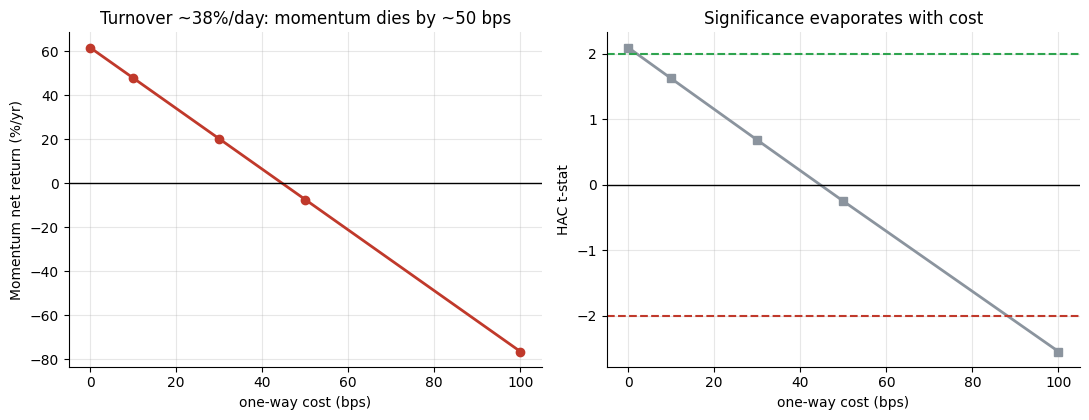

one-way turnover: 37.8%/day  (~138%/yr)


In [5]:
MC = [(0, 61.6, 2.10), (10, 47.8, 1.62), (30, 20.2, 0.68), (50, -7.4, -0.25), (100, -76.5, -2.55)]
if HAVE_REAL:
    MC = []
    for c in [0, 10, 30, 50, 100]:
        s = st.summary(st.long_short_returns(panel, sig, leg='momentum', cost_bps=c))
        MC.append((c, s['ann_return']*100, s['tstat']))
costs = [m[0] for m in MC]; anns = [m[1] for m in MC]; ts = [m[2] for m in MC]
fig, ax = plt.subplots(1, 2, figsize=(11, 4.3))
ax[0].plot(costs, anns, 'o-', c=RED, lw=2); ax[0].axhline(0, c='k', lw=1)
ax[0].set_xlabel('one-way cost (bps)'); ax[0].set_ylabel('Momentum net return (%/yr)')
ax[0].set_title(f'Turnover ~{turn:.0%}/day: momentum dies by ~50 bps')
ax[1].plot(costs, ts, 's-', c=GREY, lw=2); ax[1].axhline(2, ls='--', c=GREEN)
ax[1].axhline(-2, ls='--', c=RED); ax[1].axhline(0, c='k', lw=1)
ax[1].set_xlabel('one-way cost (bps)'); ax[1].set_ylabel('HAC t-stat')
ax[1].set_title('Significance evaporates with cost')
plt.tight_layout(); plt.show()
print(f'one-way turnover: {turn:.1%}/day  (~{turn*365:.0f}%/yr)')


> in plain words: gross momentum looks tradable, but it requires replacing almost the entire book every day. At crypto's real costs the edge is gone before you account for the impossibility of shorting thin alts. This is the textbook fate of a high-turnover, short-horizon anomaly (Novy-Marx & Velikov 2016).

## 7 -- Going further & the honest caveats

- **Survivorship.** The universe is today's liquid survivors projected backward (no LUNA/FTT). This *flatters momentum* (the winners are the survivors) and is the same bias the paper concedes inflates its own factor returns. A point-in-time universe with delistings is the proper fix -- and would most plausibly weaken the momentum side, not rescue reversal.
- **Liquidity tail.** Classical short-term reversal is a small-cap, high-cost phenomenon. Our 20 liquid tokens may simply not contain it. But the small/illiquid tail where reversal could live is precisely where the >1% spreads make it untradable -- so the tradability verdict is robust to this caveat.
- **The non-reproducible factors.** The paper's genuinely novel claims (on-chain *quality* t = 9.80, *value* t = 8.91, perp-*funding* t = 6.74) rest on paid Coin Metrics data and undisclosed composites. We tested only the price-only slice. A follow-up using free on-chain proxies (active addresses via public explorers, Binance funding API) could probe those -- a separate study.
- **Frequency.** A weekly or monthly rebalance cuts turnover ~5-20x. Whether *any* net edge (either sign) survives at low frequency is the natural next test.

*Fork this: add a point-in-time universe with dead tokens, drop to a monthly rebalance, or wire in free on-chain proxies for the paper's quality/value factors. The engine and controls are here.*